Part A 

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset and check size and information
df = pd.read_csv("../data/FishersMarket.csv")
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 8.8 KB


In [4]:
# 1. Data Cleaning - Missing values, duplicates, inconsistencies and/or outliers.

In [5]:
#Checking for mising values and handling them if present
missing_values = df.isnull().sum()
missing_values

df_cleaned = df.copy()

numeric_columns = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]

df_cleaned[numeric_columns] = df_cleaned[numeric_columns].fillna(
    df_cleaned[numeric_columns].median()
)

df_cleaned.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [6]:
#Checking for duplicate rows and handling them if present
duplicate_count = df_cleaned.duplicated().sum()

df_cleaned = df_cleaned.drop_duplicates()

duplicate_count

np.int64(0)

In [7]:
#Checking for inconsistencies
for col in numeric_columns:
    print(col, "values less than or equal to 0:", (df_cleaned[col] <= 0).sum())

Weight values less than or equal to 0: 1
Length1 values less than or equal to 0: 0
Length2 values less than or equal to 0: 0
Length3 values less than or equal to 0: 0
Height values less than or equal to 0: 0
Width values less than or equal to 0: 0


In [8]:
#Now we handle the inconsistency by replacing zero or negative values with median value of respective column
for col in numeric_columns:
    median_value = df_cleaned[df_cleaned[col]> 0][col].median()
    df_cleaned.loc[df_cleaned[col] <=0, col] = median_value

for col in numeric_columns:
    print(col,"values less than or equal to 0:", (df_cleaned[col]<= 0).sum())

Weight values less than or equal to 0: 0
Length1 values less than or equal to 0: 0
Length2 values less than or equal to 0: 0
Length3 values less than or equal to 0: 0
Height values less than or equal to 0: 0
Width values less than or equal to 0: 0


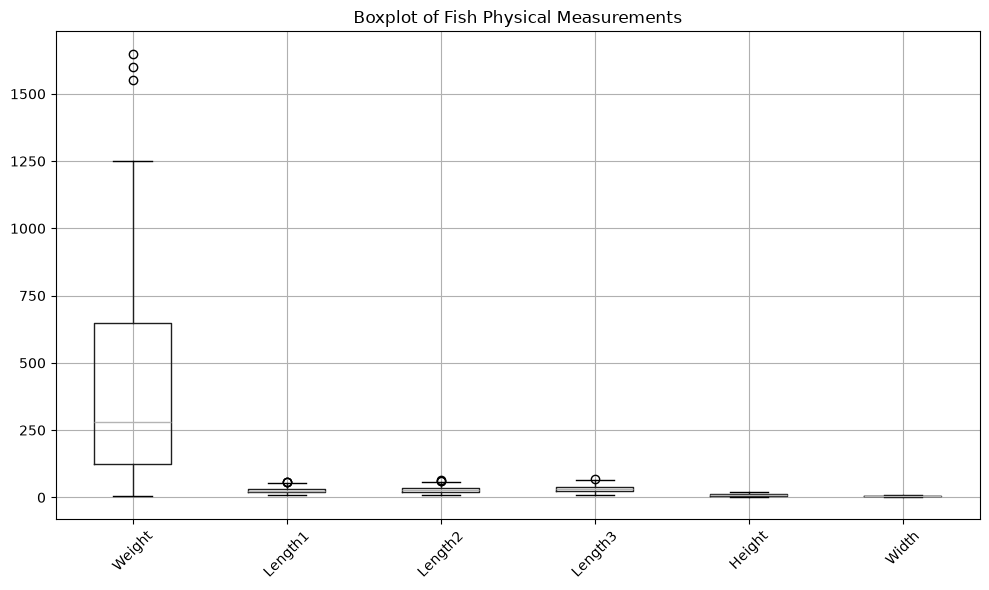

In [10]:
#Checking for outliers using boxplot
plt.figure(figsize=(10,6))
df_cleaned[numeric_columns].boxplot()
plt.title("Boxplot of Fish Physical Measurements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/boxplot_measurements.png")
plt.show()

In [11]:
#Outliers are visible in the columns, we count outliers using IQR
for col in numeric_columns:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    
    print(col, "outliers:", len(outliers))

Weight outliers: 3
Length1 outliers: 3
Length2 outliers: 3
Length3 outliers: 1
Height outliers: 0
Width outliers: 0


In [12]:
#Handling outliers by using capping
df_no_outliers = df_cleaned.copy()

for col in numeric_columns:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers[col] = np.where(
        df_no_outliers[col] < lower_bound,
        lower_bound,
        df_no_outliers[col]
    )
    
    df_no_outliers[col] = np.where(
        df_no_outliers[col] > upper_bound,
        upper_bound,
        df_no_outliers[col]
    )

df_no_outliers.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,397.101572,26.175000,28.342453,31.204403,8.970994,4.417486
std,347.032771,9.782457,10.499859,11.541386,4.286208,1.685804
min,5.900000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,122.500000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,281.500000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1441.250000,53.175000,57.250000,64.400000,18.957000,8.142000


After capping:
Weight max = 1441.25
Length1 max = 53.175
Length2 max = 57.25
Length3 max = 64.4

In [13]:
#2. Data Transformation - Perform feature scaling, encoding, and/or feature engineering

In [14]:
#Encoding - Convert species(text) to numbers for 
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_transformed = df_no_outliers.copy()

df_transformed["Species_encoded"] = label_encoder.fit_transform(df_transformed["Species"])

df_transformed[["Species", "Species_encoded"]].drop_duplicates().sort_values("Species_encoded")

,Species,Species_encoded
0,Bream,0
61,Parkki,1
72,Perch,2
128,Pike,3
35,Roach,4
145,Smelt,5
55,Whitefish,6


In [15]:
#Feature Engineering - New Features that benefit during Machine learning
df_transformed["Average_Length"] = df_transformed[["Length1", "Length2", "Length3"]].mean(axis=1)
df_transformed["Length_Difference"] = df_transformed["Length3"] - df_transformed["Length1"]

df_transformed.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Species_encoded,Average_Length,Length_Difference
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,0,26.200000,6.8
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,0,27.166667,7.2
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,0,27.166667,7.2
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,0,29.600000,7.2
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,0,29.833333,7.5


In [16]:
#Feature Scaling - Scaling all numerical input features (new ones as well)
from sklearn.preprocessing import StandardScaler

feature_columns = [
    "Weight",
    "Length1",
    "Length2",
    "Length3",
    "Height",
    "Width",
    "Average_Length",
    "Length_Difference"
]

X = df_transformed[feature_columns]
y = df_transformed["Species_encoded"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

X_scaled_df.head()

,Weight,Length1,Length2,Length3,Height,Width,Average_Length,Length_Difference
0,-0.448349,-0.305077,-0.281123,-0.104685,0.596579,-0.236529,-0.224873,0.801319
1,-0.309596,-0.223039,-0.195137,-0.000383,0.821261,-0.066579,-0.133306,0.982346
2,-0.165062,-0.233294,-0.176028,-0.009075,0.797341,0.165793,-0.133306,0.982346
3,-0.098577,0.012818,0.062822,0.199530,0.879771,0.022621,0.097193,0.982346
4,0.095099,0.033328,0.062822,0.242989,0.812835,0.426371,0.119295,1.118117


In [17]:
# 3.Data Reduction -  Techniques like feature selection, feature extraction or dimensionality reduction

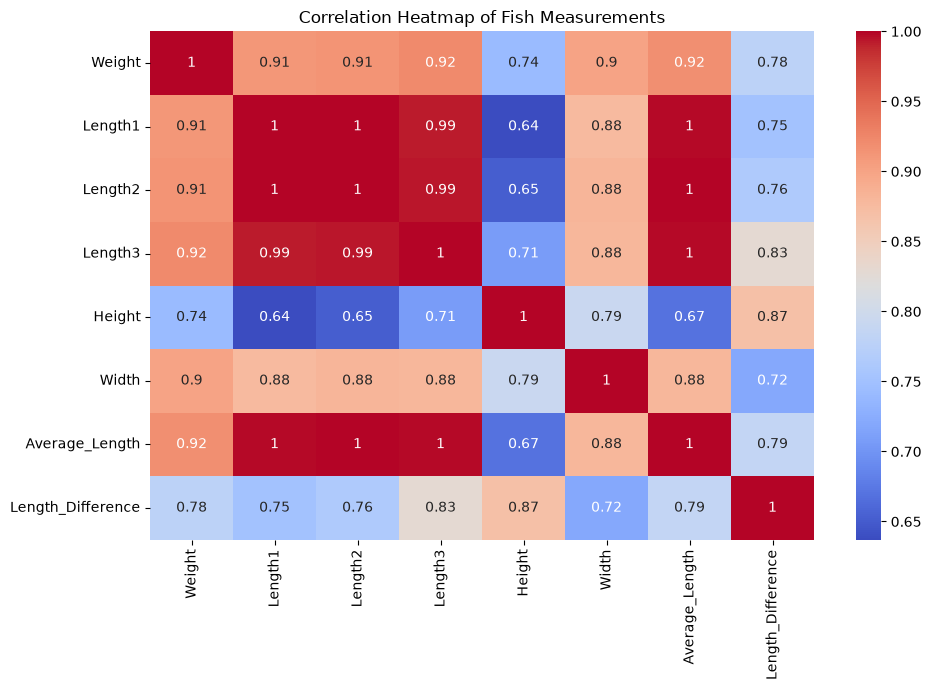

In [18]:
# Correlation Heatmap - Checks the relation between numerical features (Used to check correlation betwen each feature)
plt.figure(figsize=(10,7))
sns.heatmap(df_transformed[feature_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Fish Measurements")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png")
plt.show()

In [19]:
# Feature Selection - Selects the 5 best features from initial 8 input features
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X_scaled_df, y)

selected_features = X_scaled_df.columns[selector.get_support()]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['Length2', 'Length3', 'Height', 'Average_Length', 'Length_Difference']


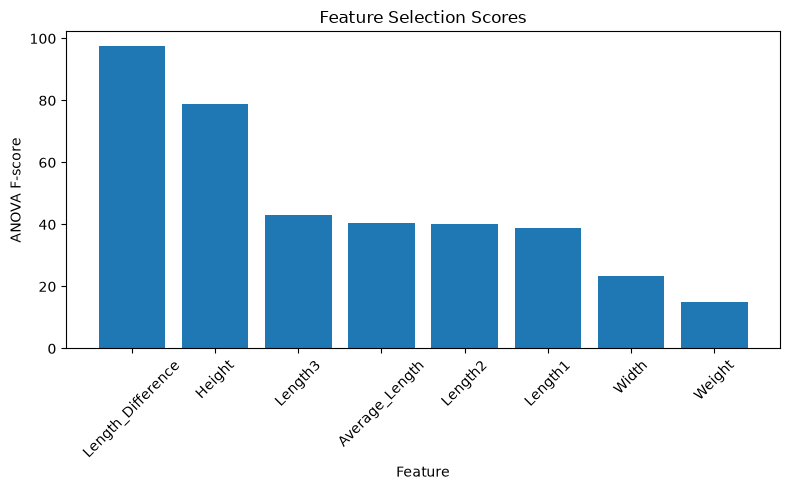

In [20]:
# Showing Feature Score graph andd how each feature was selected 
feature_scores = pd.DataFrame({
    "Feature": feature_columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False);

feature_scores

plt.figure(figsize=(8,5))
plt.bar(feature_scores["Feature"], feature_scores["Score"])
plt.title("Feature Selection Scores")
plt.xlabel("Feature")
plt.ylabel("ANOVA F-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/feature_selection_scores.png")
plt.show()

In [21]:
# Final Processed Dataset
processed_df = pd.DataFrame(X_selected, columns=selected_features)

processed_df["Species_encoded"] = y.values
processed_df["Species"] = df_transformed["Species"].values

processed_df.head()

,Length2,Length3,Height,Average_Length,Length_Difference,Species_encoded,Species
0,-0.281123,-0.104685,0.596579,-0.224873,0.801319,0,Bream
1,-0.195137,-0.000383,0.821261,-0.133306,0.982346,0,Bream
2,-0.176028,-0.009075,0.797341,-0.133306,0.982346,0,Bream
3,0.062822,0.199530,0.879771,0.097193,0.982346,0,Bream
4,0.062822,0.242989,0.812835,0.119295,1.118117,0,Bream


In [22]:
#Saving the processed dataset for Applying Machine Learning Models
processed_df.to_csv("../data/processed_FishersMarket.csv", index=False)

print("Processed dataset saved successfully.")
print("Final processed dataset shape:", processed_df.shape)

Processed dataset saved successfully.
Final processed dataset shape: (159, 7)
